# Étape 3 — Analyse complète des résultats (Régression, Cas 1)
**Version enrichie de `03_analyseReg.ipynb`** — ajoute la sélection de variables par stabilité.

**Prérequis** : avoir exécuté `ComparaisonReg_final.ipynb` puis sauvegardé PREV :
```python
# A exécuter à la fin de ComparaisonReg_final.ipynb :
PREV.to_csv("PREV.csv", index=False)
```

**Ce notebook** :
- Calcule MSE / RMSE / MAE par méthode
- Visualise les résidus (boxplot)
- Analyse la stabilité des λ Lasso
- Identifie les **variables robustes** par sélection bootstrap (Lasso + ElasticNet)

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, ElasticNetCV, RidgeCV, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold
import os

# ← Modifier si les fichiers sont ailleurs
DOSSIER_PREV    = "../FICHIERS FINAUX/"
DOSSIER_DONNEES = "../FICHIERS FINAUX/DONNEES/"
# DONNEES   = DOSSIER_DONNEES + "ozone_transf.txt"
DONNEES = pd.read_csv("https://regression-avec-python.github.io/donnees/ozone_transf.txt", header=0, sep=";", index_col=0)
DONNEES.rename(columns={"maxO3": "Y"}, inplace=True)

GRAINE = 42
kf = KFold(n_splits=10, shuffle=True, random_state=GRAINE)

## 1. Chargement de PREV.csv

In [32]:
chemin_prev = DOSSIER_PREV + "PREV.csv"

if not os.path.exists(chemin_prev):
    raise FileNotFoundError(
        f"{chemin_prev} introuvable.\n"
        "Etapes :\n"
        "  1. Ouvrir FICHIERS FINAUX/ComparaisonReg_final.ipynb\n"
        "  2. Executer toutes les cellules\n"
        "  3. Ajouter et executer : PREV.to_csv('PREV.csv', index=False)"
    )

PREV = pd.read_csv(chemin_prev)
print(f"PREV charge : {PREV.shape[0]} observations x {PREV.shape[1]} colonnes")
print(f"Methodes disponibles : {list(PREV.columns[2:])}")
print(f"Blocs CV : {PREV['bloc'].nunique()}")
PREV.head(3)

PREV charge : 1366 observations x 13 colonnes
Methodes disponibles : ['MCO', 'BIC', 'AIC', 'lasso', 'ridge', 'elastic', 'ridgeGS', 'arbre', 'foret', 'pcr', 'pls']
Blocs CV : 10


,bloc,Y,MCO,BIC,AIC,lasso,ridge,elastic,ridgeGS,arbre,foret,pcr,pls
0,2,47.6,57.494473,0.0,0.0,59.334502,57.692647,57.759069,57.671315,57.900000,59.464,57.621366,57.482855
1,3,56.2,62.899981,0.0,0.0,61.650229,62.907366,62.704213,62.907366,43.955556,56.930,61.235650,62.709865
2,8,61.8,85.985247,0.0,0.0,84.488402,85.738667,85.452462,85.751965,78.766667,74.676,87.657690,85.988956


## 2. Métriques par méthode

In [33]:
methodes = [c for c in PREV.columns if c not in ["bloc", "Y"]]      # récupération des prédictions des différents modèles
residus  = PREV[methodes].sub(PREV["Y"], axis=0)                    # pour chaque modèle : residu = Yprev - Y

metriques = pd.DataFrame(index=methodes)
metriques["MSE"]      = (residus ** 2).mean().round(2)              # MSE	Moyenne des erreurs²	Pénalise fortement les grandes erreurs
metriques["RMSE"]     = np.sqrt((residus ** 2).mean()).round(3)     # RMSE	√MSE	Même unité que Y → plus interprétable
metriques["MAE"]      = residus.abs().mean().round(2)               # MAE	Moyenne des |erreurs|	Plus robuste aux outliers que le MSE

# tri des MSE par ordre croissant (donc du meilleur modèle au moins bon)
metriques["Rang_MSE"] = metriques["MSE"].rank().astype(int)
metriques_tries = metriques.sort_values("MSE")

print("Comparaison des methodes (MSE croissante) :")
print(metriques_tries.to_string())

Comparaison des methodes (MSE croissante) :
             MSE    RMSE    MAE  Rang_MSE
foret     156.24  12.499   9.58         1
lasso     187.05  13.677  10.78         2
elastic   187.20  13.682  10.78         3
ridgeGS   187.43  13.690  10.80         4
ridge     187.45  13.691  10.80         5
MCO       187.51  13.694  10.80         6
pls       187.92  13.709  10.82         7
pcr       188.22  13.719  10.81         8
arbre     249.79  15.805  12.17         9
AIC      7745.43  88.008  84.92        10
BIC      7745.43  88.008  84.92        10


## 3. Visualisation des erreurs

/tmp/ipykernel_3716/911713337.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(residus_grouped, labels=methodes_triees, vert=False)


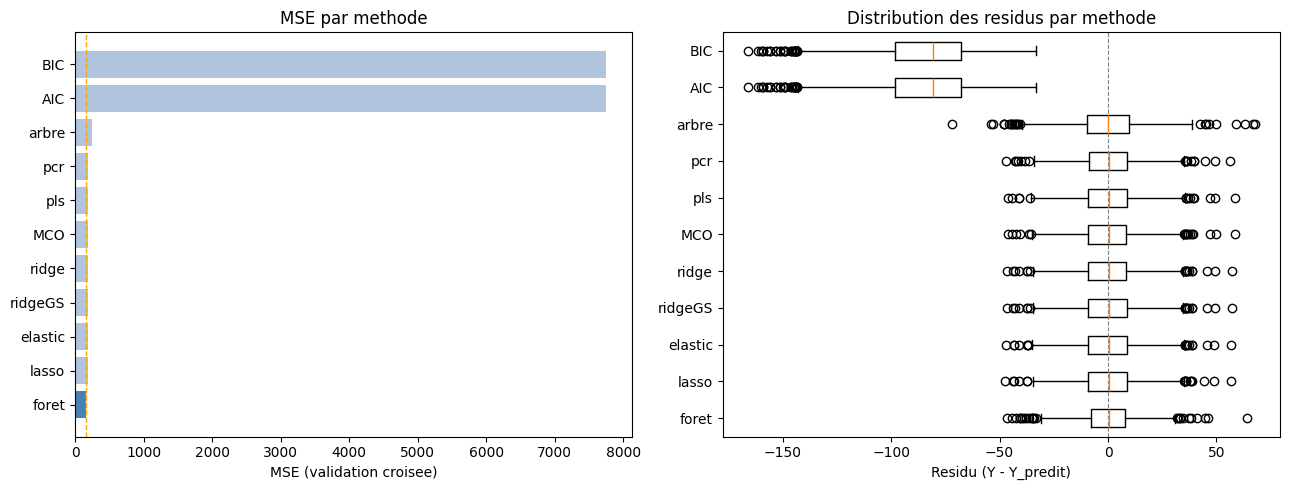

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

m = metriques_tries
colors = ["steelblue" if mse == m.MSE.min() else "lightsteelblue" for mse in m.MSE]
ax1.barh(m.index, m.MSE, color=colors)
ax1.set_xlabel("MSE (validation croisee)")
ax1.set_title("MSE par methode")
ax1.axvline(x=m.MSE.min(), color="orange", linestyle="--", linewidth=1)

methodes_triees = metriques_tries.index.tolist()
residus_grouped = [residus[m_].values for m_ in methodes_triees]
ax2.boxplot(residus_grouped, labels=methodes_triees, vert=False)
ax2.set_xlabel("Residu (Y - Y_predit)")
ax2.set_title("Distribution des residus par methode")
ax2.axvline(x=0, color="grey", linestyle="--", linewidth=0.8)

plt.tight_layout()
plt.show()

---
## 4. Sélection par stabilité (bootstrap Lasso + ElasticNet)
**Principe** (Meinshausen & Bühlmann, 2010) : on tire `N_BOOT` échantillons bootstrap, on fitte le Lasso (et l'ElasticNet) sur chacun, et on mesure la **fréquence de sélection** de chaque variable.

- Variable sélectionnée dans **> 50 %** des bootstraps → **robuste**
- Variable sélectionnée rarement → artefact, dépend de l'échantillon

**Pourquoi Lasso et ElasticNet seulement ?**
- Lasso et ElasticNet produisent des coefficients exactement nuls → sélection binaire → comptage naturel
- Ridge : conserve toutes les variables (aucun coeff = 0) → fréquence toujours 100 % → inutile
- MCO : idem Ridge
- Forêt : pas de sélection binaire → approche différente (variance des importances)

In [37]:
don = DONNEES

Y_imp   = don["Y"].values
X_df    = don.drop(columns=["Y"]).select_dtypes(include=[np.number])
nomsvar = list(X_df.columns)
X_imp   = X_df.values
print(f"{len(nomsvar)} variables : {nomsvar}")
print(f"{len(Y_imp)} observations")

21 variables : ['T6', 'T9', 'T12', 'T15', 'T18', 'Ne6', 'Ne9', 'Ne12', 'Ne15', 'Ne18', 'Vx6', 'Vy6', 'Vx9', 'Vy9', 'Vx12', 'Vy12', 'Vx15', 'Vy15', 'Vx18', 'Vy18', 'maxO3v']
1366 observations


In [38]:
from sklearn.utils import resample

N_BOOT = 100
counts_lasso = pd.Series(0, index=nomsvar)
counts_enet  = pd.Series(0, index=nomsvar)
rng_boot = np.random.default_rng(GRAINE)

for b in range(N_BOOT):
    seed_b = int(rng_boot.integers(0, 99999))
    X_boot, Y_boot = resample(X_imp, Y_imp, random_state=seed_b)

    # Lasso
    pipe_l = Pipeline([("scaler", StandardScaler()),
                       ("lasso",  LassoCV(cv=5, max_iter=5000, random_state=seed_b))])
    pipe_l.fit(X_boot, Y_boot)
    counts_lasso += (pipe_l.named_steps["lasso"].coef_ != 0).astype(int)

    # ElasticNet
    pipe_e = Pipeline([("scaler", StandardScaler()),
                       ("enet",   ElasticNetCV(cv=5, max_iter=5000, random_state=seed_b))])
    pipe_e.fit(X_boot, Y_boot)
    counts_enet += (pipe_e.named_steps["enet"].coef_ != 0).astype(int)

freq_lasso = (counts_lasso / N_BOOT).sort_values(ascending=False)
freq_enet  = (counts_enet  / N_BOOT).sort_values(ascending=False)

print(f"Frequence de selection — bootstrap Lasso ({N_BOOT} repetitions) :")
print(freq_lasso.round(3).to_string())
print(f"\nFrequence de selection — bootstrap ElasticNet ({N_BOOT} repetitions) :")
print(freq_enet.round(3).to_string())

Frequence de selection — bootstrap Lasso (100 repetitions) :
T6        1.00
T12       1.00
maxO3v    1.00
Ne12      1.00
Ne9       1.00
Vy9       0.98
Vx15      0.95
Vx12      0.90
Ne15      0.87
Vx18      0.85
Vy6       0.84
T15       0.82
Vy18      0.81
Ne18      0.76
Vx6       0.71
Vy15      0.71
Ne6       0.71
Vy12      0.62
Vx9       0.61
T9        0.41
T18       0.32

Frequence de selection — bootstrap ElasticNet (100 repetitions) :
T6        1.00
T12       1.00
maxO3v    1.00
Ne12      1.00
Ne9       1.00
Vy9       1.00
Vx12      0.99
T15       0.99
Vx15      0.99
Vx18      0.99
Ne15      0.98
Vy6       0.98
Vy15      0.96
Vy18      0.96
Vy12      0.94
Ne18      0.92
Vx9       0.92
Ne6       0.92
T9        0.90
Vx6       0.89
T18       0.85


In [39]:
# Tableau de synthese : variables stables dans l'un ou l'autre
stab_df = pd.DataFrame({
    "freq_Lasso":   freq_lasso,
    "freq_ENet":    freq_enet,
    "stable_Lasso": (freq_lasso >= 0.5).astype(int),
    "stable_ENet":  (freq_enet  >= 0.5).astype(int),
})
stab_df["stable_les_deux"] = ((stab_df.stable_Lasso == 1) & (stab_df.stable_ENet == 1)).astype(int)
stab_df = stab_df.sort_values("freq_Lasso", ascending=False)

print("Variables stables dans les DEUX methodes (> 50%) :")
print(stab_df[stab_df.stable_les_deux == 1][["freq_Lasso","freq_ENet"]].round(3).to_string())
print("\nTableau complet :")
print(stab_df.round(3).to_string())

Variables stables dans les DEUX methodes (> 50%) :
        freq_Lasso  freq_ENet
Ne12          1.00       1.00
Ne9           1.00       1.00
maxO3v        1.00       1.00
T6            1.00       1.00
T12           1.00       1.00
Vy9           0.98       1.00
Vx15          0.95       0.99
Vx12          0.90       0.99
Ne15          0.87       0.98
Vx18          0.85       0.99
Vy6           0.84       0.98
T15           0.82       0.99
Vy18          0.81       0.96
Ne18          0.76       0.92
Ne6           0.71       0.92
Vy15          0.71       0.96
Vx6           0.71       0.89
Vy12          0.62       0.94
Vx9           0.61       0.92

Tableau complet :
        freq_Lasso  freq_ENet  stable_Lasso  stable_ENet  stable_les_deux
Ne12          1.00       1.00             1            1                1
Ne9           1.00       1.00             1            1                1
maxO3v        1.00       1.00             1            1                1
T6            1.00       1.00     

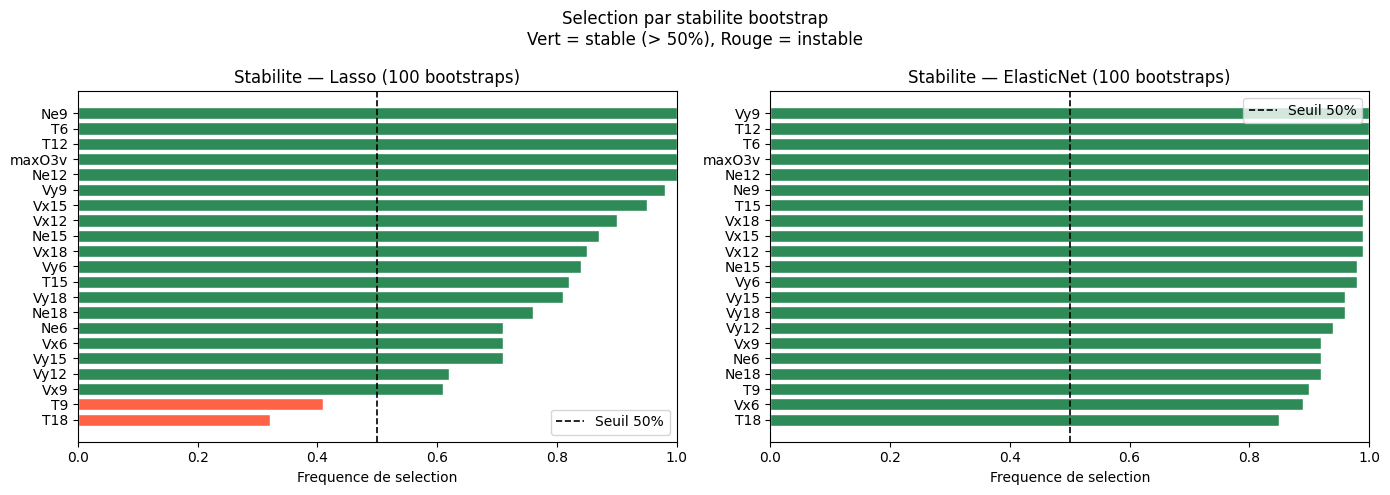

In [40]:
# Visualisation cote a cote : Lasso vs ElasticNet
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for ax, freq, titre in [
    (ax1, freq_lasso, f"Lasso ({N_BOOT} bootstraps)"),
    (ax2, freq_enet,  f"ElasticNet ({N_BOOT} bootstraps)")
]:
    freq_s = freq.sort_values(ascending=True)
    couleurs = ["seagreen" if f >= 0.5 else "tomato" for f in freq_s]
    ax.barh(freq_s.index, freq_s.values, color=couleurs, edgecolor="white")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Seuil 50%")
    ax.set_xlabel("Frequence de selection")
    ax.set_title(f"Stabilite — {titre}")
    ax.set_xlim([0, 1])
    ax.legend()

plt.suptitle("Selection par stabilite bootstrap\nVert = stable (> 50%), Rouge = instable", fontsize=12)
plt.tight_layout()
plt.show()

In [41]:
# Variables robustes : stables dans Lasso ET ElasticNet
robustes = stab_df[stab_df.stable_les_deux == 1].index.tolist()
print(f"Variables robustes (stables Lasso ET ElasticNet, {N_BOOT} bootstraps) :")
for v in robustes:
    print(f"  {v:20s}  Lasso={freq_lasso[v]:.0%}  ENet={freq_enet[v]:.0%}")

Variables robustes (stables Lasso ET ElasticNet, 100 bootstraps) :
  Ne12                  Lasso=100%  ENet=100%
  Ne9                   Lasso=100%  ENet=100%
  maxO3v                Lasso=100%  ENet=100%
  T6                    Lasso=100%  ENet=100%
  T12                   Lasso=100%  ENet=100%
  Vy9                   Lasso=98%  ENet=100%
  Vx15                  Lasso=95%  ENet=99%
  Vx12                  Lasso=90%  ENet=99%
  Ne15                  Lasso=87%  ENet=98%
  Vx18                  Lasso=85%  ENet=99%
  Vy6                   Lasso=84%  ENet=98%
  T15                   Lasso=82%  ENet=99%
  Vy18                  Lasso=81%  ENet=96%
  Ne18                  Lasso=76%  ENet=92%
  Ne6                   Lasso=71%  ENet=92%
  Vy15                  Lasso=71%  ENet=96%
  Vx6                   Lasso=71%  ENet=89%
  Vy12                  Lasso=62%  ENet=94%
  Vx9                   Lasso=61%  ENet=92%


## 5. Conclusion
Compléter après exécution :

**Performances :**
- Meilleure méthode (MSE) : ... (MSE = ...)
- Jeu de features utilisé : X / XI / XP / XIP
- Ecart avec MCO : ...

**Variables robustes (sélection par stabilité) :**
- Variables stables Lasso ET ElasticNet : ...
- Variables stables dans un seul des deux : ...
- Interprétation météorologique : ...

**Pistes d'amélioration :**
- Réactiver BIC/AIC si le nb de features est raisonnable
- Tester `X = XIP` (interactions + polynomes) si MSE encore élevée
- Augmenter `N_BOOT` (ex. 500) pour des fréquences plus stables
- Modifier le seuil de stabilité (50% → 80%) pour être plus conservateur